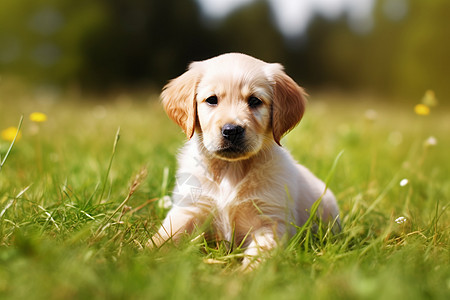

In [6]:
import glob, json, os
from PIL import Image
from tqdm import tqdm_notebook
import numpy as np
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

img_path = './image.jpg'

Image.open(img_path)

# 加载CLIP模型

In [7]:
from PIL import Image
import requests
from transformers import ChineseCLIPProcessor, ChineseCLIPModel
import torch

# 官方 openai clip 不支持中文
# https://www.modelscope.cn/models/AI-ModelScope/chinese-clip-vit-base-patch16
model = ChineseCLIPModel.from_pretrained("./model/chinese-clip-vit-base-patch16") # 中文clip模型
processor = ChineseCLIPProcessor.from_pretrained("./model/chinese-clip-vit-base-patch16") # 预处理

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

ChineseCLIPModel LOAD REPORT from: ./model/chinese-clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 自定义标签

In [18]:
# 自定义标签
texts = ["小狗", "小猫", "汽车", "树木", "小鸟", "草地"]

inputs = processor(
    text=texts, 
    return_tensors="pt", 
    padding=True
)

with torch.no_grad():
    text_feature = model.get_text_features(**inputs)
    text_feature = text_feature.pooler_output.detach().cpu().numpy()

text_feature = normalize(text_feature)
text_feature.shape

(6, 512)

### 对图像进行编码

In [19]:
image = Image.open(img_path)
image_input = processor(
    images=image,
    return_tensors="pt"
)

with torch.no_grad():
    image_feature = model.get_image_features(**image_input)
    image_feature = image_feature.pooler_output.detach().cpu().numpy() 

image_feature = normalize(image_feature)
image_feature.shape

(1, 512)

### 尝试进行相似度计算

In [ ]:
sim_result = np.dot(text_feature, image_feature.T) # 计算相似度 

print("相似度：")
for i, score in enumerate(sim_result[:, 0]):
    print(f"{texts[i]}: {score:.3f}")

# 最高分就是分类结果
best_idx = sim_result.argmax()
print("分类结果：", texts[best_idx])

相似度：
小狗: 0.425
分类结果： 小狗
